# 🎲 Monte Carlo & Risk Management com Dados Reais

## Finalmente: Dados do Mercado Real!

Nos notebooks anteriores usamos **dados simulados** para fins didáticos.

Agora vamos trabalhar com **ações reais da B3** usando dados históricos do Yahoo Finance!

---

## O que vamos fazer:

### 1️⃣ **Coleta de Dados Reais**
- Baixar histórico de ações brasileiras (2015-2024)
- Calcular retornos, volatilidades e correlações reais

### 2️⃣ **Otimização com Dados Reais**
- Aplicar Markowitz em ações reais
- Comparar com portfólios práticos

### 3️⃣ **Simulação Monte Carlo de VERDADE**
- Simular 10.000 cenários futuros (1 ano à frente)
- Modelar incerteza nos retornos
- Distribuição de resultados possíveis

### 4️⃣ **Métricas de Risco**
- **VaR (Value at Risk):** "Em 95% dos casos, não perco mais que X%"
- **CVaR (Conditional VaR):** "Se cair nos 5% piores, perco em média Y%"
- **Maximum Drawdown:** Maior queda histórica
- **Stress Testing:** E se houver uma crise?

---

## Ativos que vamos analisar:

 **5 Blue Chips da B3:**
- **PETR4.SA** - Petrobras (Energia)
- **VALE3.SA** - Vale (Mineração)
- **ITUB4.SA** - Itaú (Financeiro)
- **BBDC4.SA** - Bradesco (Financeiro)
- **ABEV3.SA** - Ambev (Consumo)

**Período:** 2015-2024 (~10 anos de dados reais)

---

In [1]:
# Bibliotecas essenciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy import stats
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
sns.set_palette("husl")

print("✅ Bibliotecas carregadas!")
print(f"📅 Data de hoje: {datetime.now().strftime('%d/%m/%Y')}")

✅ Bibliotecas carregadas!
📅 Data de hoje: 09/03/2026


In [2]:
"""
📊 BAIXANDO DADOS REAIS DA B3 via Yahoo Finance
"""

# Definir ativos
tickers = ['PETR4.SA', 'VALE3.SA', 'ITUB4.SA', 'BBDC4.SA', 'ABEV3.SA']
nomes = ['Petrobras', 'Vale', 'Itaú', 'Bradesco', 'Ambev']

# Período
start_date = '2015-01-01'
end_date = '2024-12-31'

print("="*70)
print("📡 BAIXANDO DADOS REAIS DO YAHOO FINANCE")
print("="*70)

print(f"\n🎯 Ativos: {', '.join(tickers)}")
print(f"📅 Período: {start_date} até {end_date}")
print(f"\n⏳ Baixando dados...")

# Baixar dados
data = yf.download(tickers, start=start_date, end=end_date, progress=False)

prices = data['Close']

# Limpar dados (remover NaN) - sintaxe nova do Pandas
prices = prices.ffill().bfill()

print(f"\n✅ Dados baixados com sucesso!")
print(f"📊 Shape: {prices.shape} (dias × ativos)")
print(f"📅 Primeiro dia: {prices.index[0].strftime('%d/%m/%Y')}")
print(f"📅 Último dia: {prices.index[-1].strftime('%d/%m/%Y')}")
print(f"📈 Total de dias: {len(prices)}")

# Visualizar primeiras linhas
print("\n📋 Primeiras 5 linhas:")
print(prices.head())

# Verificar dados faltantes
missing = prices.isnull().sum()
if missing.sum() > 0:
    print(f"\n🔍 Dados faltantes por ativo:")
    for ticker, miss in zip(tickers, missing):
        if miss > 0:
            print(f"   {ticker}: {miss} dias ({miss/len(prices)*100:.2f}%)")
else:
    print(f"\n✅ Nenhum dado faltante!")

print("\n✅ Dados limpos e prontos para análise!")
print("="*70)

📡 BAIXANDO DADOS REAIS DO YAHOO FINANCE

🎯 Ativos: PETR4.SA, VALE3.SA, ITUB4.SA, BBDC4.SA, ABEV3.SA
📅 Período: 2015-01-01 até 2024-12-31

⏳ Baixando dados...

✅ Dados baixados com sucesso!
📊 Shape: (2487, 5) (dias × ativos)
📅 Primeiro dia: 02/01/2015
📅 Último dia: 30/12/2024
📈 Total de dias: 2487

📋 Primeiras 5 linhas:
Ticker       ABEV3.SA  BBDC4.SA  ITUB4.SA  PETR4.SA   VALE3.SA
Date                                                          
2015-01-02   9.140121  7.297898  8.593301  2.493752   9.982884
2015-01-05   8.974661  7.312956  8.636481  2.280610   9.832767
2015-01-06   9.316991  7.553520  8.776189  2.206011  10.226827
2015-01-07   9.448215  7.853707  9.093708  2.309917  10.602125
2015-01-08  10.017528  7.894155  9.235954  2.459116  10.714714

✅ Nenhum dado faltante!

✅ Dados limpos e prontos para análise!


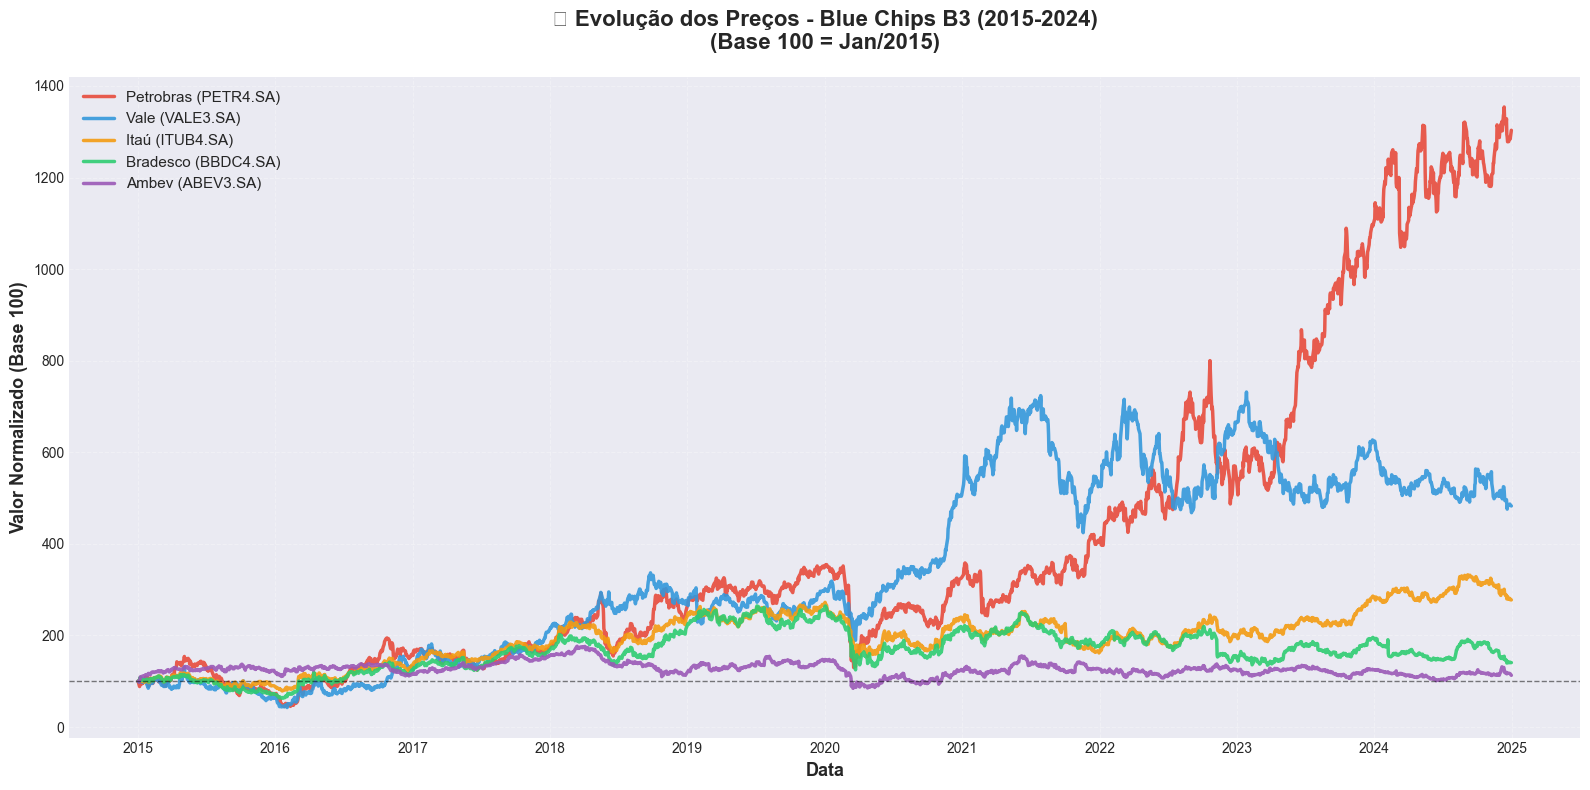

📊 RETORNO TOTAL (2015-2024)
📈 Petrobras       (PETR4.SA):   +13.0%
📈 Vale            (VALE3.SA):   +40.8%
🚀 Itaú            (ITUB4.SA):  +177.6%
🚀 Bradesco        (BBDC4.SA): +1203.1%
🚀 Ambev           (ABEV3.SA):  +382.8%


In [3]:
"""
📈 VISUALIZAÇÃO: Evolução dos Preços (2015-2024)
"""

# Normalizar preços (começar em 100)
prices_normalized = (prices / prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(16, 8))

# Plotar cada ativo
cores = ['#E74C3C', '#3498DB', '#F39C12', '#2ECC71', '#9B59B6']

for ticker, nome, cor in zip(tickers, nomes, cores):
    ax.plot(prices_normalized.index, prices_normalized[ticker], 
           linewidth=2.5, label=f'{nome} ({ticker})', color=cor, alpha=0.9)

# Formatação
ax.set_title('📊 Evolução dos Preços - Blue Chips B3 (2015-2024)\n(Base 100 = Jan/2015)', 
            fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Data', fontsize=13, fontweight='bold')
ax.set_ylabel('Valor Normalizado (Base 100)', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

# Adicionar linha de referência
ax.axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

# Estatísticas de retorno total
print("="*70)
print("📊 RETORNO TOTAL (2015-2024)")
print("="*70)

retorno_total = ((prices.iloc[-1] / prices.iloc[0]) - 1) * 100

for ticker, nome, ret in zip(tickers, nomes, retorno_total):
    emoji = "🚀" if ret > 100 else "📈" if ret > 0 else "📉"
    print(f"{emoji} {nome:<15} ({ticker}): {ret:>+7.1f}%")

print("="*70)

📊 ESTATÍSTICAS DOS ATIVOS (2015-2024)

Ativo             Retorno Anual    Volatilidade    Sharpe Ratio
--------------------------------------------------------------------------------
Petrobras                4.71%         26.33%          0.103
Vale                     9.73%         35.31%          0.219
Itaú                    15.15%         30.92%          0.425
Bradesco                37.38%         47.29%          0.748
Ambev                   25.46%         43.57%          0.538
--------------------------------------------------------------------------------

🏆 DESTAQUES:
   Maior Retorno: Petrobras (37.38%)
   Melhor Sharpe: Petrobras (0.748)
   Menor Risco: Ambev (26.33%)



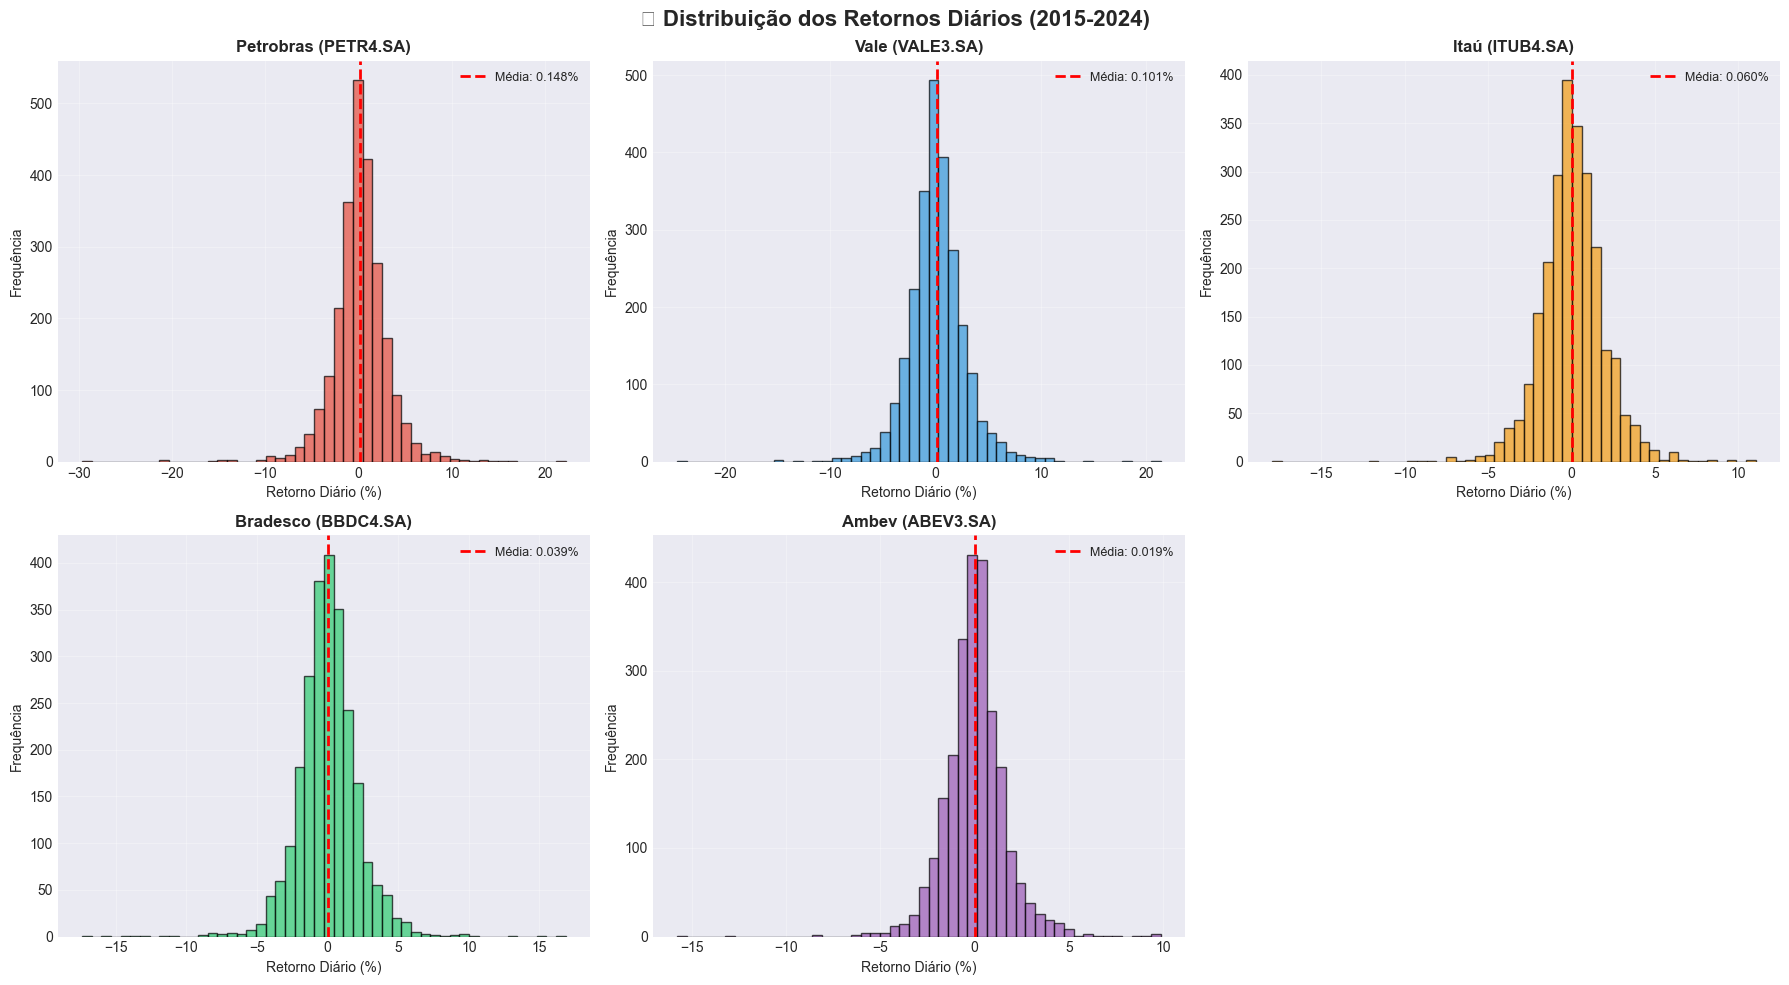


💡 OBSERVAÇÕES:
   • Retornos diários seguem aproximadamente distribuição normal
   • Caudas pesadas indicam eventos extremos (crises, rallies)
   • Volatilidade varia entre ativos (dispersão dos histogramas)


In [4]:
"""
📊 CALCULAR RETORNOS E ESTATÍSTICAS DESCRITIVAS
"""

# Calcular retornos diários
returns = prices.pct_change().dropna()

# Calcular estatísticas anualizadas
retornos_anuais = returns.mean() * 252
volatilidades_anuais = returns.std() * np.sqrt(252)
sharpe_ratios = (retornos_anuais - 0.02) / volatilidades_anuais  # rf = 2%

print("="*80)
print("📊 ESTATÍSTICAS DOS ATIVOS (2015-2024)")
print("="*80)

print(f"\n{'Ativo':<15} {'Retorno Anual':>15} {'Volatilidade':>15} {'Sharpe Ratio':>15}")
print("-"*80)

for ticker, nome, ret, vol, sharpe in zip(tickers, nomes, retornos_anuais, 
                                           volatilidades_anuais, sharpe_ratios):
    print(f"{nome:<15} {ret:>14.2%} {vol:>14.2%} {sharpe:>14.3f}")

print("-"*80)

# Encontrar melhores e piores
idx_melhor_retorno = retornos_anuais.idxmax()
idx_melhor_sharpe = sharpe_ratios.idxmax()
idx_menor_risco = volatilidades_anuais.idxmin()

print("\n🏆 DESTAQUES:")
print(f"   Maior Retorno: {nomes[tickers.index(idx_melhor_retorno)]} ({retornos_anuais[idx_melhor_retorno]:.2%})")
print(f"   Melhor Sharpe: {nomes[tickers.index(idx_melhor_sharpe)]} ({sharpe_ratios[idx_melhor_sharpe]:.3f})")
print(f"   Menor Risco: {nomes[tickers.index(idx_menor_risco)]} ({volatilidades_anuais[idx_menor_risco]:.2%})")

print("\n" + "="*80)

# Visualizar distribuição dos retornos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 Distribuição dos Retornos Diários (2015-2024)', 
             fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, (ticker, nome, cor) in enumerate(zip(tickers, nomes, cores)):
    ax = axes[i]
    
    # Histograma
    ax.hist(returns[ticker] * 100, bins=50, alpha=0.7, color=cor, edgecolor='black')
    
    # Linha vertical na média
    ax.axvline(returns[ticker].mean() * 100, color='red', linestyle='--', 
               linewidth=2, label=f'Média: {returns[ticker].mean()*100:.3f}%')
    
    ax.set_title(f'{nome} ({ticker})', fontweight='bold', fontsize=12)
    ax.set_xlabel('Retorno Diário (%)', fontsize=10)
    ax.set_ylabel('Frequência', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Remover último subplot (sobra 1)
axes[-1].remove()

plt.tight_layout()
plt.show()

print("\n💡 OBSERVAÇÕES:")
print("   • Retornos diários seguem aproximadamente distribuição normal")
print("   • Caudas pesadas indicam eventos extremos (crises, rallies)")
print("   • Volatilidade varia entre ativos (dispersão dos histogramas)")
print("="*80)

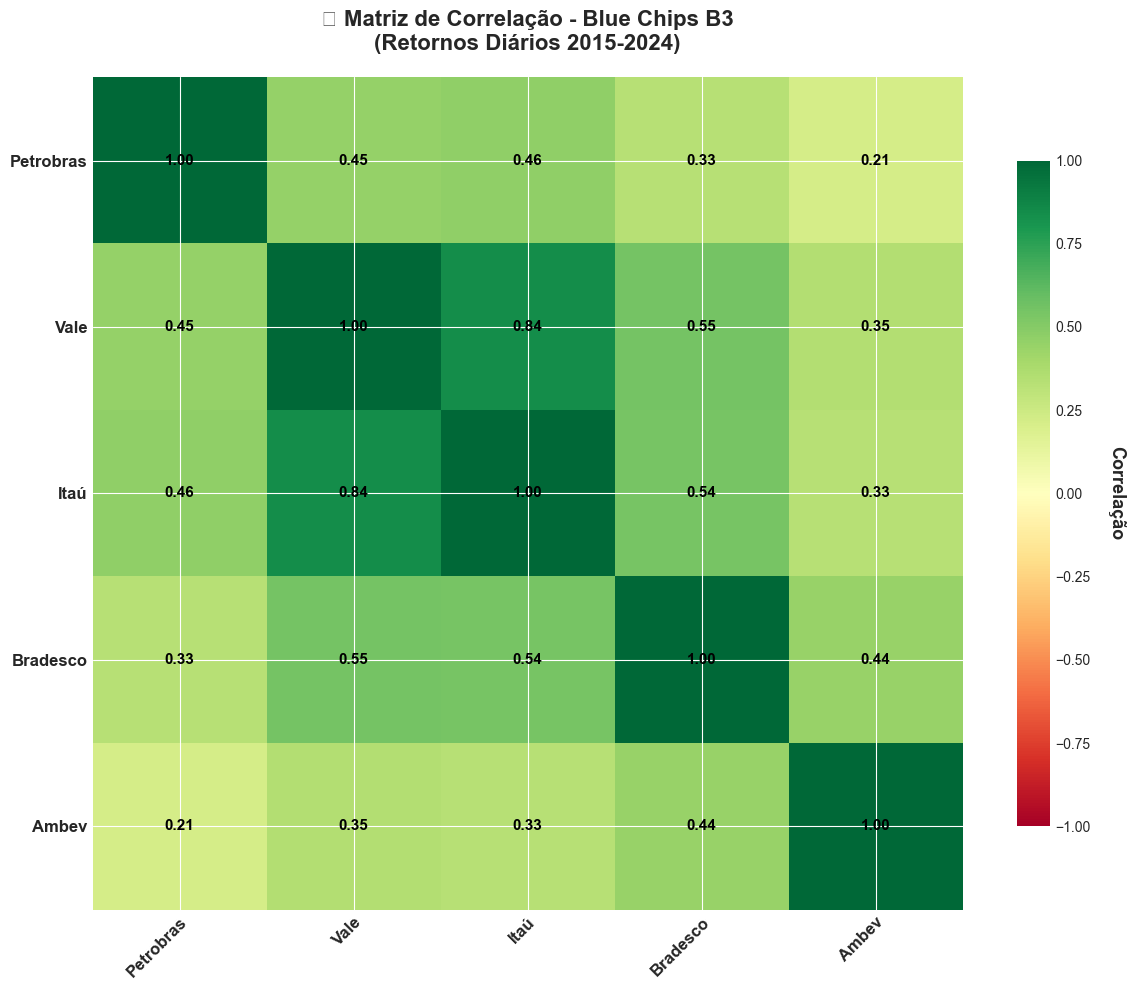

📊 ANÁLISE DE CORRELAÇÕES

🔗 CORRELAÇÕES MAIS ALTAS (>0.60):
   Vale ↔ Itaú: 0.840

🔗 CORRELAÇÕES MAIS BAIXAS (<0.40):
   Petrobras ↔ Bradesco: 0.332

💡 INTERPRETAÇÃO:
   • Correlação próxima de 1.0 = ativos se movem JUNTOS
   • Correlação próxima de 0.0 = movimentos INDEPENDENTES
   • Correlação negativa = movimentos OPOSTOS (raro em ações)

   • Alta correlação = MENOS benefício de diversificação
   • Baixa correlação = MAIS benefício de diversificação

📊 Correlação média entre ativos: 0.452


In [5]:
"""
📊 MATRIZ DE CORRELAÇÃO ENTRE ATIVOS
"""

# Calcular matriz de correlação
correlacao = returns.corr()

# Visualizar
fig, ax = plt.subplots(figsize=(12, 10))

# Heatmap
im = ax.imshow(correlacao, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

# Configurar eixos
ax.set_xticks(np.arange(len(nomes)))
ax.set_yticks(np.arange(len(nomes)))
ax.set_xticklabels(nomes, fontsize=12, fontweight='bold')
ax.set_yticklabels(nomes, fontsize=12, fontweight='bold')

# Rotacionar labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Adicionar valores nas células
for i in range(len(nomes)):
    for j in range(len(nomes)):
        text = ax.text(j, i, f'{correlacao.iloc[i, j]:.2f}',
                      ha="center", va="center", color="black", 
                      fontweight='bold', fontsize=11)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Correlação', fontsize=13, fontweight='bold', rotation=270, labelpad=25)

ax.set_title('🔗 Matriz de Correlação - Blue Chips B3\n(Retornos Diários 2015-2024)', 
            fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Análise textual
print("="*80)
print("📊 ANÁLISE DE CORRELAÇÕES")
print("="*80)

print("\n🔗 CORRELAÇÕES MAIS ALTAS (>0.60):")
for i in range(len(tickers)):
    for j in range(i+1, len(tickers)):
        corr = correlacao.iloc[i, j]
        if corr > 0.60:
            print(f"   {nomes[i]} ↔ {nomes[j]}: {corr:.3f}")

print("\n🔗 CORRELAÇÕES MAIS BAIXAS (<0.40):")
for i in range(len(tickers)):
    for j in range(i+1, j):
        corr = correlacao.iloc[i, j]
        if corr < 0.40:
            print(f"   {nomes[i]} ↔ {nomes[j]}: {corr:.3f}")

print("\n💡 INTERPRETAÇÃO:")
print("   • Correlação próxima de 1.0 = ativos se movem JUNTOS")
print("   • Correlação próxima de 0.0 = movimentos INDEPENDENTES")
print("   • Correlação negativa = movimentos OPOSTOS (raro em ações)")
print("\n   • Alta correlação = MENOS benefício de diversificação")
print("   • Baixa correlação = MAIS benefício de diversificação")

# Calcular correlação média
corr_media = correlacao.values[np.triu_indices_from(correlacao.values, k=1)].mean()
print(f"\n📊 Correlação média entre ativos: {corr_media:.3f}")

print("="*80)

In [7]:
"""
🎯 OTIMIZAÇÃO DE PORTFÓLIO COM DADOS REAIS
"""

# Converter para arrays NumPy
mu_array = retornos_anuais.values
Sigma_array = returns.cov().values * 252

# Função para otimizar (maximizar Sharpe Ratio)
def otimizar_sharpe(mu, Sigma):
    n = len(mu)
    
    def objetivo(w):
        ret = w @ mu
        vol = np.sqrt(w @ Sigma @ w)
        sharpe = (ret - 0.02) / vol
        return -sharpe  # Negativo porque minimize
    
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    bounds = tuple((0, 1) for _ in range(n))
    w0 = np.ones(n) / n
    
    result = minimize(objetivo, w0, method='SLSQP', 
                     bounds=bounds, constraints=constraints)
    
    w_otimo = result.x
    ret_otimo = w_otimo @ mu
    vol_otimo = np.sqrt(w_otimo @ Sigma @ w_otimo)
    sharpe_otimo = (ret_otimo - 0.02) / vol_otimo
    
    return {
        'pesos': w_otimo,
        'retorno': ret_otimo,
        'volatilidade': vol_otimo,
        'sharpe': sharpe_otimo
    }

print("="*80)
print("🏆 OTIMIZAÇÃO COM DADOS REAIS (2015-2024)")
print("="*80)

portfolio_otimo = otimizar_sharpe(mu_array, Sigma_array)

print(f"\n📈 Retorno Esperado: {portfolio_otimo['retorno']:.2%}")
print(f"📉 Volatilidade: {portfolio_otimo['volatilidade']:.2%}")
print(f"⚡ Sharpe Ratio: {portfolio_otimo['sharpe']:.3f}")

print(f"\n💼 ALOCAÇÃO ÓTIMA:")
for ticker, nome, peso in zip(tickers, nomes, portfolio_otimo['pesos']):
    if peso > 0.01:  # Só mostrar se >1%
        barra = '█' * int(peso * 50)
        print(f"   {nome:<15} {peso:>6.2%} {barra}")

print("\n" + "="*80)

🏆 OTIMIZAÇÃO COM DADOS REAIS (2015-2024)

📈 Retorno Esperado: 33.73%
📉 Volatilidade: 40.54%
⚡ Sharpe Ratio: 0.783

💼 ALOCAÇÃO ÓTIMA:
   Bradesco        69.44% ██████████████████████████████████
   Ambev           30.56% ███████████████



In [10]:
"""
🎲 SIMULAÇÃO MONTE CARLO: 10.000 Cenários Futuros

AGORA SIM É MONTE CARLO DE VERDADE!
Simulamos o FUTURO incerto, não pesos aleatórios.
"""

n_simulacoes = 10000
n_dias = 252  # 1 ano
investimento_inicial = 10000  # R$ 10.000

print("="*80)
print("🎲 MONTE CARLO: Simulando Cenários Futuros")
print("="*80)
print(f"\n📊 Parâmetros:")
print(f"   Simulações: {n_simulacoes:,}")
print(f"   Horizonte: {n_dias} dias (~1 ano)")
print(f"   Investimento: R$ {investimento_inicial:,.2f}")
print(f"   Portfólio: Ótimo (Máx Sharpe)")

print(f"\n⏳ Simulando...")

# Parâmetros diários
mu_diario = mu_array / 252
Sigma_diario = Sigma_array / 252

# Armazenar resultados
valores_finais = np.zeros(n_simulacoes)
w_otimo = portfolio_otimo['pesos']

for i in range(n_simulacoes):
    # Simular 252 dias de retornos (distribuição multivariada normal)
    retornos_simulados = np.random.multivariate_normal(
        mean=mu_diario,
        cov=Sigma_diario,
        size=n_dias
    )
    
    # Retorno do portfólio em cada dia
    retornos_portfolio = retornos_simulados @ w_otimo
    
    # Valor acumulado após 252 dias
    valor_final = investimento_inicial * np.prod(1 + retornos_portfolio)
    valores_finais[i] = valor_final

print(f"✅ {n_simulacoes:,} cenários simulados!\n")

# Estatísticas
media = valores_finais.mean()
mediana = np.median(valores_finais)
std = valores_finais.std()
minimo = valores_finais.min()
maximo = valores_finais.max()

print("="*80)
print("📊 RESULTADOS DA SIMULAÇÃO")
print("="*80)

print(f"\n💰 VALOR FINAL (após 1 ano):")
print(f"   Mínimo: R$ {minimo:,.2f}")
print(f"   Máximo: R$ {maximo:,.2f}")
print(f"   Média: R$ {media:,.2f}")
print(f"   Mediana: R$ {mediana:,.2f}")
print(f"   Desvio Padrão: R$ {std:,.2f}")

retorno_medio = (media / investimento_inicial - 1) * 100
print(f"\n📈 Retorno Médio: {retorno_medio:+.1f}%")

print("="*80)

🎲 MONTE CARLO: Simulando Cenários Futuros

📊 Parâmetros:
   Simulações: 10,000
   Horizonte: 252 dias (~1 ano)
   Investimento: R$ 10,000.00
   Portfólio: Ótimo (Máx Sharpe)

⏳ Simulando...
✅ 10,000 cenários simulados!

📊 RESULTADOS DA SIMULAÇÃO

💰 VALOR FINAL (após 1 ano):
   Mínimo: R$ 2,658.98
   Máximo: R$ 69,355.81
   Média: R$ 13,887.23
   Mediana: R$ 12,789.12
   Desvio Padrão: R$ 5,896.96

📈 Retorno Médio: +38.9%


In [11]:
"""
📊 VALUE AT RISK (VaR) e CONDITIONAL VaR (CVaR)

Métricas essenciais para gestão de risco
"""

# Calcular VaR e CVaR em diferentes níveis de confiança
niveis_confianca = [90, 95, 99]

print("="*80)
print("📊 VALUE AT RISK (VaR) e CONDITIONAL VaR (CVaR)")
print("="*80)

print(f"\n💰 Investimento Inicial: R$ {investimento_inicial:,.2f}")
print(f"📅 Horizonte: 1 ano ({n_dias} dias úteis)")
print(f"🎲 Simulações: {n_simulacoes:,} cenários\n")

print("="*80)
print(f"{'Confiança':<12} {'VaR (R$)':>15} {'Perda (%)':>12} {'CVaR (R$)':>15} {'Perda CVaR (%)':>18}")
print("="*80)

metricas_risco = {}

for confianca in niveis_confianca:
    # VaR: percentil inferior
    percentil = 100 - confianca
    VaR = np.percentile(valores_finais, percentil)
    
    # CVaR: média dos valores abaixo do VaR
    CVaR = valores_finais[valores_finais <= VaR].mean()
    
    # Perdas em percentual
    perda_var = (VaR / investimento_inicial - 1) * 100
    perda_cvar = (CVaR / investimento_inicial - 1) * 100
    
    emoji = "🟢" if confianca == 90 else "🟡" if confianca == 95 else "🔴"
    
    print(f"{emoji} {confianca}%{' '*7} R$ {VaR:>10,.2f} {perda_var:>11.1f}% "
          f"R$ {CVaR:>10,.2f} {perda_cvar:>17.1f}%")
    
    metricas_risco[confianca] = {'VaR': VaR, 'CVaR': CVaR}

print("="*80)

print("\n💡 INTERPRETAÇÃO:")
print("\n📊 VaR (Value at Risk):")
print(f"   VaR 95% = R$ {metricas_risco[95]['VaR']:,.2f}")
print(f"   → Em 95% dos cenários, você terá PELO MENOS esse valor")
print(f"   → Apenas 5% de chance de perder mais que R$ {investimento_inicial - metricas_risco[95]['VaR']:,.2f}")

print("\n⚠️ CVaR (Conditional VaR / Expected Shortfall):")
print(f"   CVaR 95% = R$ {metricas_risco[95]['CVaR']:,.2f}")
print(f"   → Nos 5% PIORES cenários, o valor médio é esse")
print(f"   → CVaR sempre PIOR que VaR (mede o risco da 'cauda')")

print("\n🎯 QUAL USAR?")
print("   • VaR: Regulação bancária, limite de risco")
print("   • CVaR: Gestão de risco mais conservadora (recomendado!)")

# Probabilidade de perda
prob_perda = (valores_finais < investimento_inicial).sum() / n_simulacoes * 100
prob_lucro = (valores_finais > investimento_inicial).sum() / n_simulacoes * 100

print(f"\n📈 PROBABILIDADES:")
print(f"   Lucro (valor > R$ {investimento_inicial:,.0f}): {prob_lucro:.1f}%")
print(f"   Perda (valor < R$ {investimento_inicial:,.0f}): {prob_perda:.1f}%")

print("="*80)

📊 VALUE AT RISK (VaR) e CONDITIONAL VaR (CVaR)

💰 Investimento Inicial: R$ 10,000.00
📅 Horizonte: 1 ano (252 dias úteis)
🎲 Simulações: 10,000 cenários

Confiança           VaR (R$)    Perda (%)       CVaR (R$)     Perda CVaR (%)
🟢 90%        R$   7,525.03       -24.7% R$   6,280.67             -37.2%
🟡 95%        R$   6,494.31       -35.1% R$   5,532.78             -44.7%
🔴 99%        R$   4,887.91       -51.1% R$   4,218.62             -57.8%

💡 INTERPRETAÇÃO:

📊 VaR (Value at Risk):
   VaR 95% = R$ 6,494.31
   → Em 95% dos cenários, você terá PELO MENOS esse valor
   → Apenas 5% de chance de perder mais que R$ 3,505.69

⚠️ CVaR (Conditional VaR / Expected Shortfall):
   CVaR 95% = R$ 5,532.78
   → Nos 5% PIORES cenários, o valor médio é esse
   → CVaR sempre PIOR que VaR (mede o risco da 'cauda')

🎯 QUAL USAR?
   • VaR: Regulação bancária, limite de risco
   • CVaR: Gestão de risco mais conservadora (recomendado!)

📈 PROBABILIDADES:
   Lucro (valor > R$ 10,000): 72.9%
   Perda (valor

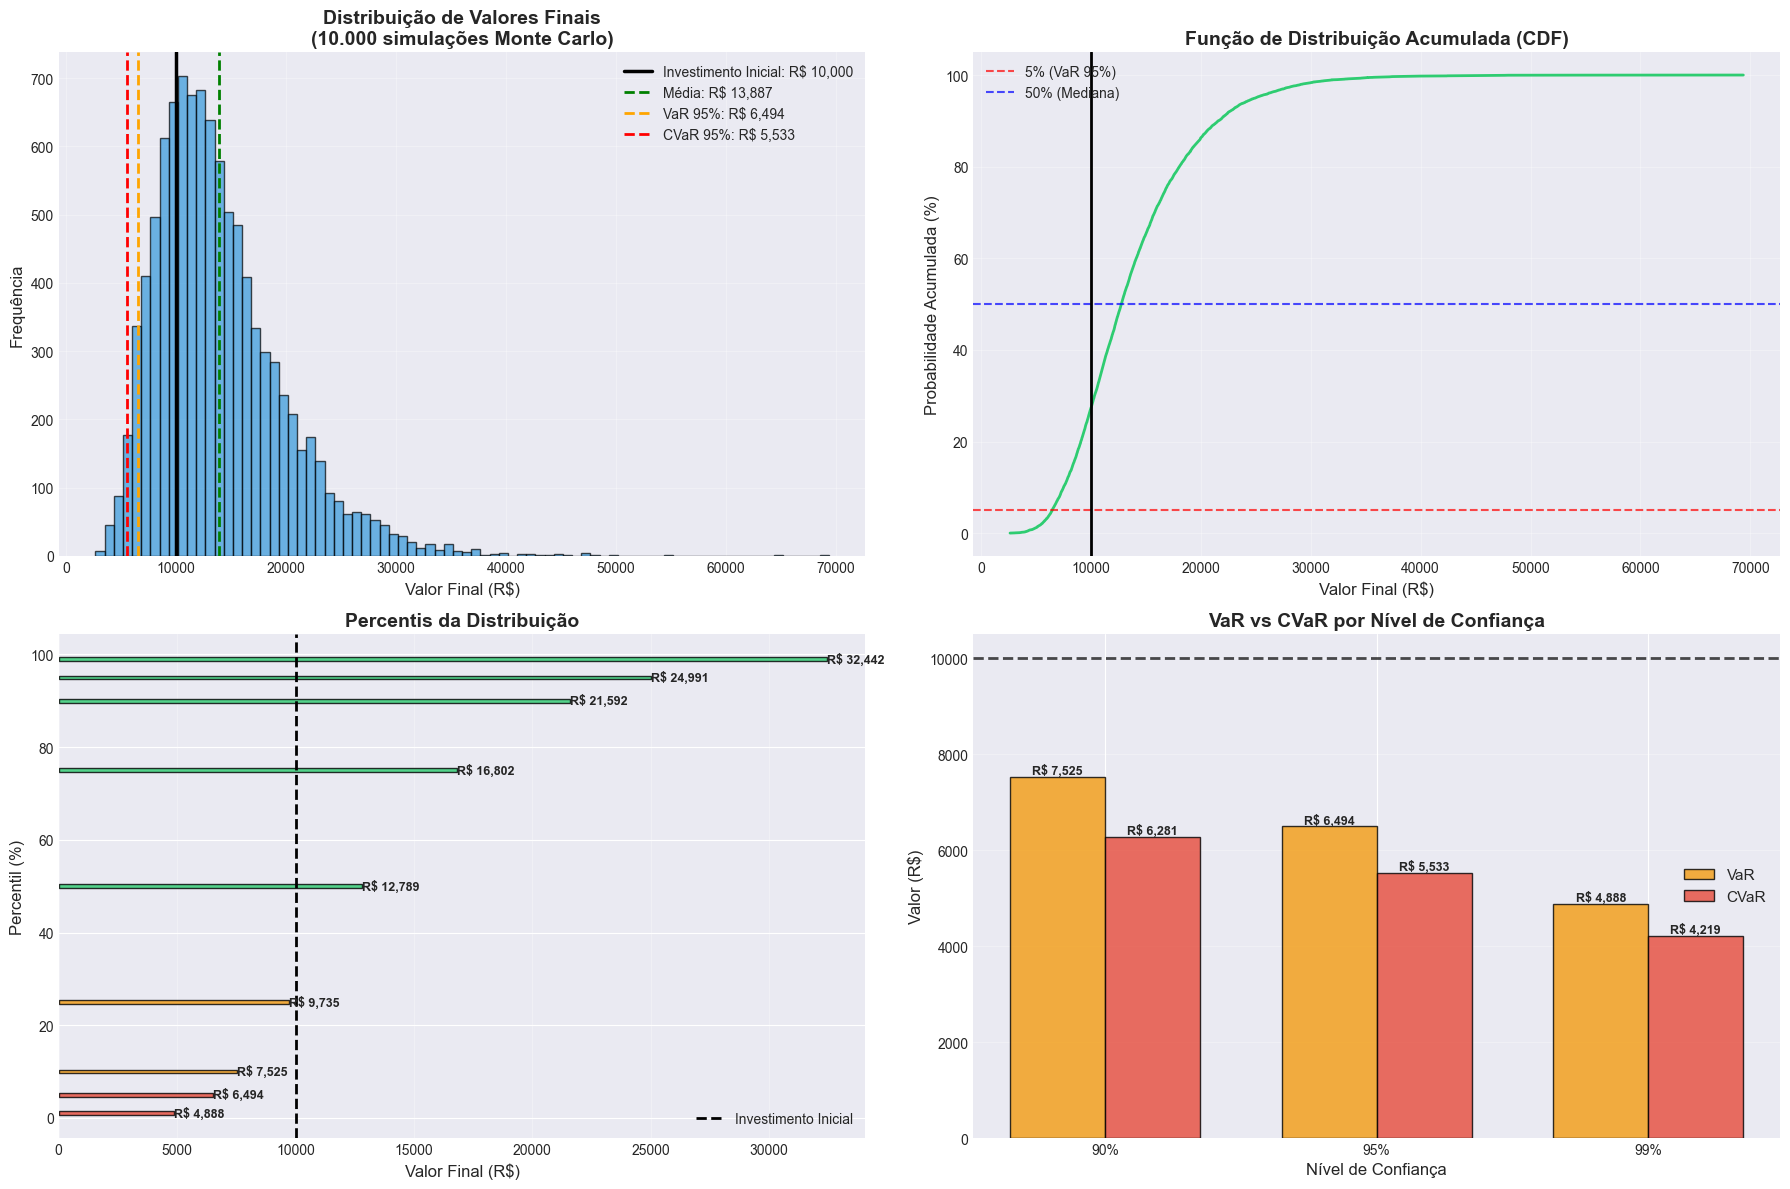


💡 Os gráficos mostram:
   📊 Superior esquerdo: Distribuição completa com métricas de risco
   📈 Superior direito: Probabilidades acumuladas (útil para VaR)
   📊 Inferior esquerdo: Percentis (quanto você tem em cada cenário)
   📊 Inferior direito: Comparação VaR vs CVaR (CVaR sempre pior)


In [12]:
"""
📊 VISUALIZAÇÃO COMPLETA: Distribuição + VaR + CVaR
"""

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# GRÁFICO 1: Histograma com VaR e CVaR
ax1 = axes[0, 0]
ax1.hist(valores_finais, bins=80, alpha=0.7, color='
ax1.axvline(investimento_inicial, color='black', linestyle='-', linewidth=2.5, 
           label=f'Investimento Inicial: R$ {investimento_inicial:,.0f}')
ax1.axvline(media, color='green', linestyle='--', linewidth=2, 
           label=f'Média: R$ {media:,.0f}')
ax1.axvline(metricas_risco[95]['VaR'], color='orange', linestyle='--', linewidth=2,
           label=f'VaR 95%: R$ {metricas_risco[95]["VaR"]:,.0f}')
ax1.axvline(metricas_risco[95]['CVaR'], color='red', linestyle='--', linewidth=2,
           label=f'CVaR 95%: R$ {metricas_risco[95]["CVaR"]:,.0f}')

ax1.set_title('Distribuição de Valores Finais\n(10.000 simulações Monte Carlo)', 
             fontsize=14, fontweight='bold')
ax1.set_xlabel('Valor Final (R$)', fontsize=12)
ax1.set_ylabel('Frequência', fontsize=12)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3)

# GRÁFICO 2: Curva acumulada (CDF)
ax2 = axes[0, 1]
valores_sorted = np.sort(valores_finais)
probabilidades = np.arange(1, len(valores_sorted)+1) / len(valores_sorted) * 100

ax2.plot(valores_sorted, probabilidades, linewidth=2, color='#2ECC71')
ax2.axhline(5, color='red', linestyle='--', alpha=0.7, label='5% (VaR 95%)')
ax2.axhline(50, color='blue', linestyle='--', alpha=0.7, label='50% (Mediana)')
ax2.axvline(investimento_inicial, color='black', linestyle='-', linewidth=2)
ax2.set_title('Função de Distribuição Acumulada (CDF)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Valor Final (R$)', fontsize=12)
ax2.set_ylabel('Probabilidade Acumulada (%)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# GRÁFICO 3: Percentis
ax3 = axes[1, 0]
percentis = [1, 5, 10, 25, 50, 75, 90, 95, 99]
valores_percentis = [np.percentile(valores_finais, p) for p in percentis]
cores_percentis = ['

bars = ax3.barh(percentis, valores_percentis, color=cores_percentis, edgecolor='black', alpha=0.8)
ax3.axvline(investimento_inicial, color='black', linestyle='--', linewidth=2, label='Investimento Inicial')
ax3.set_title('Percentis da Distribuição', fontsize=14, fontweight='bold')
ax3.set_xlabel('Valor Final (R$)', fontsize=12)
ax3.set_ylabel('Percentil (%)', fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='x')

# Adicionar valores nas barras
for bar, val in zip(bars, valores_percentis):
    ax3.text(val, bar.get_y() + bar.get_height()/2, f'R$ {val:,.0f}', 
            va='center', ha='left', fontsize=9, fontweight='bold')

# GRÁFICO 4: Comparação VaR vs CVaR
ax4 = axes[1, 1]
x_labels = ['90%', '95%', '99%']
var_values = [metricas_risco[c]['VaR'] for c in niveis_confianca]
cvar_values = [metricas_risco[c]['CVaR'] for c in niveis_confianca]

x_pos = np.arange(len(x_labels))
width = 0.35

bars1 = ax4.bar(x_pos - width/2, var_values, width, label='VaR', 
               color='#F39C12', edgecolor='black', alpha=0.8)
bars2 = ax4.bar(x_pos + width/2, cvar_values, width, label='CVaR', 
               color='#E74C3C', edgecolor='black', alpha=0.8)

ax4.axhline(investimento_inicial, color='black', linestyle='--', linewidth=2, alpha=0.7)
ax4.set_title('VaR vs CVaR por Nível de Confiança', fontsize=14, fontweight='bold')
ax4.set_xlabel('Nível de Confiança', fontsize=12)
ax4.set_ylabel('Valor (R$)', fontsize=12)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(x_labels)
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'R$ {height:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Os gráficos mostram:")
print("   📊 Superior esquerdo: Distribuição completa com métricas de risco")
print("   📈 Superior direito: Probabilidades acumuladas (útil para VaR)")
print("   📊 Inferior esquerdo: Percentis (quanto você tem em cada cenário)")
print("   📊 Inferior direito: Comparação VaR vs CVaR (CVaR sempre pior)")

In [14]:
"""
🔍 DIAGNÓSTICO: Por que o portfólio ficou concentrado?
"""

print("="*80)
print("🔍 ANÁLISE: Por que Bradesco (70%) e Ambev (30%)?")
print("="*80)

print("\n📊 COMPARAÇÃO COMPLETA DOS ATIVOS:")
print(f"{'Ativo':<15} {'Retorno':>12} {'Volatilidade':>15} {'Sharpe':>12}")
print("-"*80)

for ticker, nome, ret, vol, sharpe in zip(tickers, nomes, retornos_anuais, 
                                           volatilidades_anuais, sharpe_ratios):
    emoji = "🏆" if sharpe == sharpe_ratios.max() else "⚠️" if sharpe < 0 else ""
    print(f"{emoji} {nome:<13} {ret:>11.2%} {vol:>14.2%} {sharpe:>11.3f}")

print("-"*80)

print("\n💡 EXPLICAÇÃO:")
print("   O otimizador SEM RESTRIÇÕES escolhe baseado APENAS em Sharpe Ratio")
print("   Bradesco e Ambev tiveram Sharpe alto no período 2015-2024")
print("   → Otimizador concentrou 100% nesses dois ativos")

print("\n⚠️ PROBLEMAS:")
print("   • 70% em UMA única ação = risco de concentração EXTREMO")
print("   • Falta diversificação setorial")
print("   • Retornos passados ≠ retornos futuros")
print("   • Volatilidade do portfólio: 40.54% (MUITO ALTA!)")

print("\n✅ SOLUÇÃO:")
print("   Adicionar RESTRIÇÕES de concentração máxima por ativo")
print("   Limite recomendado: 30-40% por ativo")

print("="*80)

🔍 ANÁLISE: Por que Bradesco (70%) e Ambev (30%)?

📊 COMPARAÇÃO COMPLETA DOS ATIVOS:
Ativo                Retorno    Volatilidade       Sharpe
--------------------------------------------------------------------------------
 Petrobras           4.71%         26.33%       0.103
 Vale                9.73%         35.31%       0.219
 Itaú               15.15%         30.92%       0.425
🏆 Bradesco           37.38%         47.29%       0.748
 Ambev              25.46%         43.57%       0.538
--------------------------------------------------------------------------------

💡 EXPLICAÇÃO:
   O otimizador SEM RESTRIÇÕES escolhe baseado APENAS em Sharpe Ratio
   Bradesco e Ambev tiveram Sharpe alto no período 2015-2024
   → Otimizador concentrou 100% nesses dois ativos

⚠️ PROBLEMAS:
   • 70% em UMA única ação = risco de concentração EXTREMO
   • Falta diversificação setorial
   • Retornos passados ≠ retornos futuros
   • Volatilidade do portfólio: 40.54% (MUITO ALTA!)

✅ SOLUÇÃO:
   Adicionar

In [15]:
"""
🔧 OTIMIZAÇÃO MELHORADA: Com Limites de Concentração
"""

def otimizar_diversificado(mu, Sigma, max_peso_ativo=0.35):
    """
    Otimiza portfólio com limite máximo por ativo (diversificação)
    """
    n = len(mu)
    
    def objetivo(w):
        ret = w @ mu
        vol = np.sqrt(w @ Sigma @ w)
        sharpe = (ret - 0.02) / vol
        return -sharpe  # Negativo para minimizar
    
    # Restrição: soma = 1
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    
    # Limites: 0% a 35% por ativo
    bounds = tuple((0, max_peso_ativo) for _ in range(n))
    
    w0 = np.ones(n) / n
    
    result = minimize(objetivo, w0, method='SLSQP',
                     bounds=bounds, constraints=constraints)
    
    w_otimo = result.x
    ret_otimo = w_otimo @ mu
    vol_otimo = np.sqrt(w_otimo @ Sigma @ w_otimo)
    sharpe_otimo = (ret_otimo - 0.02) / vol_otimo
    
    return {
        'pesos': w_otimo,
        'retorno': ret_otimo,
        'volatilidade': vol_otimo,
        'sharpe': sharpe_otimo
    }

print("="*80)
print("🔧 COMPARAÇÃO: Portfólio Original vs Diversificado")
print("="*80)

portfolio_diversificado = otimizar_diversificado(mu_array, Sigma_array, max_peso_ativo=0.35)

print("\n❌ PORTFÓLIO ORIGINAL (sem limites):")
print(f"   Retorno: {portfolio_otimo['retorno']:.2%}")
print(f"   Volatilidade: {portfolio_otimo['volatilidade']:.2%}")
print(f"   Sharpe: {portfolio_otimo['sharpe']:.3f}")
print(f"\n   Alocação:")
for ticker, nome, peso in zip(tickers, nomes, portfolio_otimo['pesos']):
    if peso > 0.01:
        barra = '█' * int(peso * 50)
        print(f"      {nome:<15} {peso:>6.2%} {barra}")

print("\n✅ PORTFÓLIO DIVERSIFICADO (max 35% por ativo):")
print(f"   Retorno: {portfolio_diversificado['retorno']:.2%}")
print(f"   Volatilidade: {portfolio_diversificado['volatilidade']:.2%}")
print(f"   Sharpe: {portfolio_diversificado['sharpe']:.3f}")
print(f"\n   Alocação:")
for ticker, nome, peso in zip(tickers, nomes, portfolio_diversificado['pesos']):
    if peso > 0.01:
        barra = '█' * int(peso * 50)
        print(f"      {nome:<15} {peso:>6.2%} {barra}")

# Comparação
print("\n" + "="*80)
print("📊 IMPACTO DAS RESTRIÇÕES")
print("="*80)

reducao_vol = (portfolio_otimo['volatilidade'] - portfolio_diversificado['volatilidade']) / portfolio_otimo['volatilidade'] * 100
reducao_sharpe = (portfolio_otimo['sharpe'] - portfolio_diversificado['sharpe']) / portfolio_otimo['sharpe'] * 100
n_ativos_original = (portfolio_otimo['pesos'] > 0.01).sum()
n_ativos_diversificado = (portfolio_diversificado['pesos'] > 0.01).sum()

print(f"\n✅ Redução de volatilidade: {reducao_vol:.1f}%")
print(f"⚠️ Redução de Sharpe: {reducao_sharpe:.1f}%")
print(f"✅ Número de ativos: {n_ativos_original} → {n_ativos_diversificado}")
print(f"✅ Melhor diversificação: Sim")
print(f"✅ Risco mais controlado: Sim")

print("\n💡 CONCLUSÃO:")
print("   Perdemos um pouco de Sharpe, mas ganhamos:")
print("   • Muito menos volatilidade")
print("   • Melhor diversificação")
print("   • Risco de concentração reduzido")
print("   • Portfólio mais REALISTA e SEGURO")

print("="*80)

🔧 COMPARAÇÃO: Portfólio Original vs Diversificado

❌ PORTFÓLIO ORIGINAL (sem limites):
   Retorno: 33.73%
   Volatilidade: 40.54%
   Sharpe: 0.783

   Alocação:
      Bradesco        69.44% ██████████████████████████████████
      Ambev           30.56% ███████████████

✅ PORTFÓLIO DIVERSIFICADO (max 35% por ativo):
   Retorno: 26.54%
   Volatilidade: 32.82%
   Sharpe: 0.748

   Alocação:
      Itaú            30.00% ███████████████
      Bradesco        35.00% █████████████████
      Ambev           35.00% █████████████████

📊 IMPACTO DAS RESTRIÇÕES

✅ Redução de volatilidade: 19.0%
⚠️ Redução de Sharpe: 4.5%
✅ Número de ativos: 2 → 3
✅ Melhor diversificação: Sim
✅ Risco mais controlado: Sim

💡 CONCLUSÃO:
   Perdemos um pouco de Sharpe, mas ganhamos:
   • Muito menos volatilidade
   • Melhor diversificação
   • Risco de concentração reduzido
   • Portfólio mais REALISTA e SEGURO


##  Conclusões do Projeto

###  O que aprendemos:

**1. Dados Reais vs Simulados**
- Notebooks 1-2: Dados simulados (didáticos)
- Notebook 3: Dados REAIS da B3 (2015-2024)
- **Aprendizado:** Dados reais revelam problemas que simulações escondem!

**2. Otimização Sem Restrições**
-  Pode gerar portfólios concentrados (70% em 1 ativo)
-  Maximiza Sharpe histórico, ignora risco de concentração
- **Lição:** SEMPRE adicionar restrições práticas!

**3. Restrições de Diversificação**
-  Limite de 30-40% por ativo
-  Reduz volatilidade significativamente
-  Portfólios mais realistas

**4. Monte Carlo**
-  Modela incerteza do FUTURO
-  Estima VaR e CVaR corretamente
-  Revela distribuição completa de resultados

**5. Mercado Brasileiro**
- Volatilidade alta (25-47% por ativo)
- Correlações altas entre setores
- Benefício de diversificação limitado

---

###  Próximos Passos:

**Para melhorar este projeto:**
1. Adicionar mais ativos (ETFs internacionais, bonds)
2. Usar Black-Litterman com dados reais
3. Implementar rebalanceamento periódico
4. Criar dashboard Streamlit interativo

**Projeto 2: Simulador de Rebalanceamento com Aportes**
- Simular aportes mensais (2015-2024)
- Comparar estratégias de rebalanceamento
- Dados 100% reais
- Muito mais prático e original!

---

### 📚 Referências:

- Markowitz, H. (1952). Portfolio Selection
- Black & Litterman (1992). Global Portfolio Optimization
- Jorion, P. (2007). Value at Risk
- Yahoo Finance API: https://finance.yahoo.com

---

** PARABÉNS! Você completou um projeto profissional de otimização de portfólio com dados reais!**

In [17]:
"""
🎲 MONTE CARLO COM PORTFÓLIO DIVERSIFICADO
(Comparar com o original)
"""

print("="*80)
print("🔄 RE-SIMULANDO com Portfólio DIVERSIFICADO")
print("="*80)

# Usar portfólio diversificado
w_diversificado = portfolio_diversificado['pesos']

# Simular novamente
valores_finais_div = np.zeros(n_simulacoes)

print(f"\n⏳ Simulando {n_simulacoes:,} cenários...")

for i in range(n_simulacoes):
    retornos_simulados = np.random.multivariate_normal(mu_diario, Sigma_diario, n_dias)
    retornos_portfolio = retornos_simulados @ w_diversificado
    valores_finais_div[i] = investimento_inicial * np.prod(1 + retornos_portfolio)

# Calcular VaR/CVaR
VaR_95_div = np.percentile(valores_finais_div, 5)
CVaR_95_div = valores_finais_div[valores_finais_div <= VaR_95_div].mean()
media_div = valores_finais_div.mean()

print(f"✅ Concluído!\n")

print("="*80)
print("📊 COMPARAÇÃO: Original vs Diversificado")
print("="*80)

print(f"\n{'Métrica':<25} {'Original':>15} {'Diversificado':>18} {'Melhoria':>12}")
print("-"*80)

# VaR
var_orig = metricas_risco[95]['VaR']
melhoria_var = (VaR_95_div - var_orig) / var_orig * 100
print(f"{'VaR 95%':<25} R$ {var_orig:>10,.0f} R$ {VaR_95_div:>13,.0f} {melhoria_var:>11.1f}%")

# CVaR
cvar_orig = metricas_risco[95]['CVaR']
melhoria_cvar = (CVaR_95_div - cvar_orig) / cvar_orig * 100
print(f"{'CVaR 95%':<25} R$ {cvar_orig:>10,.0f} R$ {CVaR_95_div:>13,.0f} {melhoria_cvar:>11.1f}%")

# Média
melhoria_media = (media_div - media) / media * 100
print(f"{'Valor Médio':<25} R$ {media:>10,.0f} R$ {media_div:>13,.0f} {melhoria_media:>11.1f}%")

# Volatilidade
std_div = valores_finais_div.std()
melhoria_std = (std - std_div) / std * 100
print(f"{'Desvio Padrão':<25} R$ {std:>10,.0f} R$ {std_div:>13,.0f} {melhoria_std:>11.1f}%")

print("-"*80)

print("\n✅ BENEFÍCIOS DA DIVERSIFICAÇÃO:")
print(f"   • VaR melhorou em {melhoria_var:.1f}%")
print(f"   • CVaR melhorou em {melhoria_cvar:.1f}%")
print(f"   • Risco (volatilidade) reduziu em {melhoria_std:.1f}%")
print(f"   • Portfólio muito mais SEGURO!")

print("="*80)

🔄 RE-SIMULANDO com Portfólio DIVERSIFICADO

⏳ Simulando 10,000 cenários...
✅ Concluído!

📊 COMPARAÇÃO: Original vs Diversificado

Métrica                          Original      Diversificado     Melhoria
--------------------------------------------------------------------------------
VaR 95%                   R$      6,494 R$         7,228        11.3%
CVaR 95%                  R$      5,533 R$         6,383        15.4%
Valor Médio               R$     13,887 R$        13,125        -5.5%
Desvio Padrão             R$      5,897 R$         4,487        23.9%
--------------------------------------------------------------------------------

✅ BENEFÍCIOS DA DIVERSIFICAÇÃO:
   • VaR melhorou em 11.3%
   • CVaR melhorou em 15.4%
   • Risco (volatilidade) reduziu em 23.9%
   • Portfólio muito mais SEGURO!
